In [5]:
import pandas as pd

# Load the Excel file into a pandas DataFrame
file_path = '/content/Travel_Hospitality_Dataset.xlsx'
df = pd.read_excel(file_path)

# Strip whitespace from column names to prevent KeyError issues
df.columns = df.columns.str.strip()

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Print all column names to verify
print("\nDataFrame Columns (after stripping whitespace):")
print(df.columns.tolist())

First 5 rows of the dataset:


,Column1,CANCELLED,LEAD TIME,ARRIVAL DATE YEAR,ARRIVAL DATE MONTHS,STAYS IN WEEKEND NIGHTS,STAYS IN WEEK NIGHTS,ADULTS,CHILDREN,BABIES,COUNTRY,MARKET SEGEMENT,DISTRIBUTION CHANNEL,PREVIOUS CANCELLATION,RESERVED ROOM TYPE,BOOKING CHANGES,DEPOSITE TYPE,ADDRESS,CUSTOMER TYPE
0,City Hotel,1,105,2025,February,0,8,4,0,0,GBR,Corporate,Offline,5,C,3,Refundable,211.55,Group
1,City Hotel,0,146,2025,September,2,5,1,0,0,AUS,Groups,Offline,1,A,0,Refundable,131.88,Group
2,Resort Hotel,1,200,2025,March,1,7,2,0,0,USA,Groups,Offline,2,B,1,Refundable,86.34,Contract
3,City Hotel,0,218,2025,May,3,14,3,2,0,USA,Groups,Travel Agent,5,C,0,Refundable,148.74,Contract
4,City Hotel,0,79,2025,November,0,14,2,2,1,CAN,Corporate,Online,2,B,0,No Deposit,195.43,Transient



DataFrame Columns (after stripping whitespace):
['Column1', 'CANCELLED', 'LEAD TIME', 'ARRIVAL DATE YEAR', 'ARRIVAL DATE MONTHS', 'STAYS IN WEEKEND NIGHTS', 'STAYS IN WEEK NIGHTS', 'ADULTS', 'CHILDREN', 'BABIES', 'COUNTRY', 'MARKET SEGEMENT', 'DISTRIBUTION CHANNEL', 'PREVIOUS CANCELLATION', 'RESERVED ROOM TYPE', 'BOOKING CHANGES', 'DEPOSITE TYPE', 'ADDRESS', 'CUSTOMER TYPE']


In [6]:
print(df.columns.tolist())

['Column1', 'CANCELLED', 'LEAD TIME', 'ARRIVAL DATE YEAR', 'ARRIVAL DATE MONTHS', 'STAYS IN WEEKEND NIGHTS', 'STAYS IN WEEK NIGHTS', 'ADULTS', 'CHILDREN', 'BABIES', 'COUNTRY', 'MARKET SEGEMENT', 'DISTRIBUTION CHANNEL', 'PREVIOUS CANCELLATION', 'RESERVED ROOM TYPE', 'BOOKING CHANGES', 'DEPOSITE TYPE', 'ADDRESS', 'CUSTOMER TYPE']


## Statistical Tests Documentation

### Correlation Analysis

**Purpose:** Correlation analysis is used to measure the strength and direction of a linear relationship between two quantitative variables. The correlation coefficient (commonly Pearson's *r*) ranges from -1 to +1:

*   **+1:** Perfect positive linear relationship (as one variable increases, the other increases proportionally).
*   **-1:** Perfect negative linear relationship (as one variable increases, the other decreases proportionally).
*   **0:** No linear relationship.

**Interpretation:**
*   A correlation coefficient close to 1 or -1 indicates a strong relationship.
*   A coefficient close to 0 indicates a weak or no linear relationship.
*   It's important to note that correlation does not imply causation.

**Example (Python - using pandas):**

```python
# Calculate the correlation matrix for numerical columns
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)

# Or, specifically between two columns, e.g., 'column1' and 'column2'
correlation_value = df['column1'].corr(df['column2'])
print(f"Correlation between column1 and column2: {correlation_value}")
```

### Chi-Square Test (χ²)

**Purpose:** The Chi-Square test is used to determine if there is a significant association between two categorical variables. It compares the observed frequencies in categories with the frequencies that would be expected if there were no association between the variables.

**Hypotheses:**
*   **Null Hypothesis (H₀):** There is no association between the two categorical variables (they are independent).
*   **Alternative Hypothesis (H₁):** There is an association between the two categorical variables (they are dependent).

**Interpretation:**
*   A small p-value (typically < 0.05) suggests that you reject the null hypothesis, indicating a significant association between the variables.
*   A large p-value suggests that you fail to reject the null hypothesis, meaning there is no significant association.

**Example (Python - using scipy.stats):**

```python
from scipy.stats import chi2_contingency

# Create a contingency table (cross-tabulation) of the two categorical variables
contingency_table = pd.crosstab(df['categorical_var1'], df['categorical_var2'])
print("Contingency Table:\n", contingency_table)

# Perform the Chi-Square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.3f}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:\n", expected)

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant association between the two variables.")
else:
    print("Fail to reject the null hypothesis: There is no significant association between the two variables.")
```

### T-Test

**Purpose:** A T-test is used to compare the means of two groups to determine if they are significantly different from each other. It's commonly used when the population standard deviation is unknown and the sample size is small.

**Types of T-tests:**
*   **Independent Samples T-test:** Compares the means of two independent groups (e.g., sales performance of two different marketing campaigns).
*   **Paired Samples T-test:** Compares the means of the same group at two different times or under two different conditions (e.g., blood pressure before and after treatment).
*   **One-Sample T-test:** Compares the mean of a single group against a known population mean.

**Hypotheses (for Independent Samples T-test):**
*   **Null Hypothesis (H₀):** The means of the two groups are equal.
*   **Alternative Hypothesis (H₁):** The means of the two groups are not equal.

**Interpretation:**
*   A small p-value (typically < 0.05) suggests that you reject the null hypothesis, indicating a significant difference between the group means.
*   A large p-value suggests that you fail to reject the null hypothesis, meaning there is no significant difference.

**Example (Python - using scipy.stats for Independent Samples T-test):**

```python
from scipy.stats import ttest_ind

# Assuming you have a numerical variable 'value' and a categorical variable 'group' with two levels
group1 = df[df['group_variable'] == 'GroupA']['numerical_variable']
group2 = df[df['group_variable'] == 'GroupB']['numerical_variable']

# Perform the independent samples t-test
t_statistic, p_value = ttest_ind(group1, group2, equal_var=True) # Set equal_var=False if variances are not equal

print(f"\nT-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference between the means of Group A and Group B.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between the means of Group A and Group B.")
```

In [7]:
# --- Correlation Analysis with 'CANCELLED' ---
print("\n--- Correlation Analysis with 'CANCELLED' ---")

# Select numerical columns for correlation, including 'CANCELLED'
numerical_cols = [
    'CANCELLED',
    'LEAD TIME',
    'STAYS IN WEEKEND NIGHTS',
    'STAYS IN WEEK NIGHTS',
    'ADULTS',
    'CHILDREN',
    'BABIES',
    'PREVIOUS CANCELLATION',
    'ADDRESS' # Assuming 'ADDRESS' is a numerical value like a price or booking amount
]

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Display correlation with 'CANCELLED'
print("Correlation of numerical features with 'CANCELLED':\n", correlation_matrix['CANCELLED'].sort_values(ascending=False))



--- Correlation Analysis with 'CANCELLED' ---
Correlation of numerical features with 'CANCELLED':
 CANCELLED                  1.000000
LEAD TIME                  0.296478
ADDRESS                    0.069480
STAYS IN WEEKEND NIGHTS    0.069459
BABIES                    -0.083333
CHILDREN                  -0.104713
ADULTS                    -0.187695
PREVIOUS CANCELLATION     -0.205798
STAYS IN WEEK NIGHTS      -0.248322
Name: CANCELLED, dtype: float64


In [8]:
# --- Chi-Square Test for association with 'CANCELLED' ---
print("\n--- Chi-Square Test for association with 'CANCELLED' ---")

from scipy.stats import chi2_contingency

# Example 1: Association between 'CANCELLED' and 'Column1' (Hotel Type)
print("\nChi-Square Test: CANCELLED vs. Hotel Type ('Column1')")
contingency_table_hotel = pd.crosstab(df['CANCELLED'], df['Column1'])
print("Contingency Table (CANCELLED vs. Column1):\n", contingency_table_hotel)
chi2_hotel, p_value_hotel, dof_hotel, expected_hotel = chi2_contingency(contingency_table_hotel)
print(f"Chi-square statistic: {chi2_hotel:.2f}")
print(f"P-value: {p_value_hotel:.3f}")
if p_value_hotel < 0.05:
    print("Conclusion: Significant association between CANCELLED and Hotel Type.")
else:
    print("Conclusion: No significant association between CANCELLED and Hotel Type.")

# Example 2: Association between 'CANCELLED' and 'DEPOSITE TYPE'
print("\nChi-Square Test: CANCELLED vs. Deposite Type")
contingency_table_deposit = pd.crosstab(df['CANCELLED'], df['DEPOSITE TYPE'])
print("Contingency Table (CANCELLED vs. DEPOSITE TYPE):\n", contingency_table_deposit)
chi2_deposit, p_value_deposit, dof_deposit, expected_deposit = chi2_contingency(contingency_table_deposit)
print(f"Chi-square statistic: {chi2_deposit:.2f}")
print(f"P-value: {p_value_deposit:.3f}")
if p_value_deposit < 0.05:
    print("Conclusion: Significant association between CANCELLED and Deposite Type.")
else:
    print("Conclusion: No significant association between CANCELLED and Deposite Type.")



--- Chi-Square Test for association with 'CANCELLED' ---

Chi-Square Test: CANCELLED vs. Hotel Type ('Column1')
Contingency Table (CANCELLED vs. Column1):
 Column1    City Hotel  Resort Hotel
CANCELLED                          
0                   7             3
1                   6             6
Chi-square statistic: 0.26
P-value: 0.607
Conclusion: No significant association between CANCELLED and Hotel Type.

Chi-Square Test: CANCELLED vs. Deposite Type
Contingency Table (CANCELLED vs. DEPOSITE TYPE):
 DEPOSITE TYPE  No Deposit  Non Refund  Refundable
CANCELLED                                        
0                       1           4           5
1                       3           2           7
Chi-square statistic: 1.83
P-value: 0.400
Conclusion: No significant association between CANCELLED and Deposite Type.


In [9]:
# --- T-Test for difference in means based on 'CANCELLED' status ---
print("\n--- T-Test for difference in means based on 'CANCELLED' status ---")

from scipy.stats import ttest_ind

# Separate data into two groups: Cancelled (1) and Not Cancelled (0)
not_cancelled_lead_time = df[df['CANCELLED'] == 0]['LEAD TIME']
cancelled_lead_time = df[df['CANCELLED'] == 1]['LEAD TIME']

# Perform independent samples t-test on 'LEAD TIME'
print("\nT-Test: Difference in 'LEAD TIME' between Cancelled and Not Cancelled bookings")
t_statistic_lead_time, p_value_lead_time = ttest_ind(not_cancelled_lead_time, cancelled_lead_time, equal_var=False) # Assuming unequal variances as a safer default

print(f"Mean LEAD TIME for Not Cancelled: {not_cancelled_lead_time.mean():.2f}")
print(f"Mean LEAD TIME for Cancelled: {cancelled_lead_time.mean():.2f}")
print(f"T-statistic: {t_statistic_lead_time:.2f}")
print(f"P-value: {p_value_lead_time:.3f}")

if p_value_lead_time < 0.05:
    print("Conclusion: Significant difference in LEAD TIME between Cancelled and Not Cancelled bookings.")
else:
    print("Conclusion: No significant difference in LEAD TIME between Cancelled and Not Cancelled bookings.")

# Example 2: Difference in 'ADDRESS' (assuming it's a numerical booking value) between Cancelled and Not Cancelled bookings
print("\nT-Test: Difference in 'ADDRESS' between Cancelled and Not Cancelled bookings")
not_cancelled_address = df[df['CANCELLED'] == 0]['ADDRESS']
cancelled_address = df[df['CANCELLED'] == 1]['ADDRESS']

t_statistic_address, p_value_address = ttest_ind(not_cancelled_address, cancelled_address, equal_var=False)

print(f"Mean ADDRESS for Not Cancelled: {not_cancelled_address.mean():.2f}")
print(f"Mean ADDRESS for Cancelled: {cancelled_address.mean():.2f}")
print(f"T-statistic: {t_statistic_address:.2f}")
print(f"P-value: {p_value_address:.3f}")

if p_value_address < 0.05:
    print("Conclusion: Significant difference in ADDRESS between Cancelled and Not Cancelled bookings.")
else:
    print("Conclusion: No significant difference in ADDRESS between Cancelled and Not Cancelled bookings.")



--- T-Test for difference in means based on 'CANCELLED' status ---

T-Test: Difference in 'LEAD TIME' between Cancelled and Not Cancelled bookings
Mean LEAD TIME for Not Cancelled: 141.80
Mean LEAD TIME for Cancelled: 206.00
T-statistic: -1.40
P-value: 0.176
Conclusion: No significant difference in LEAD TIME between Cancelled and Not Cancelled bookings.

T-Test: Difference in 'ADDRESS' between Cancelled and Not Cancelled bookings
Mean ADDRESS for Not Cancelled: 174.23
Mean ADDRESS for Cancelled: 184.40
T-statistic: -0.32
P-value: 0.756
Conclusion: No significant difference in ADDRESS between Cancelled and Not Cancelled bookings.


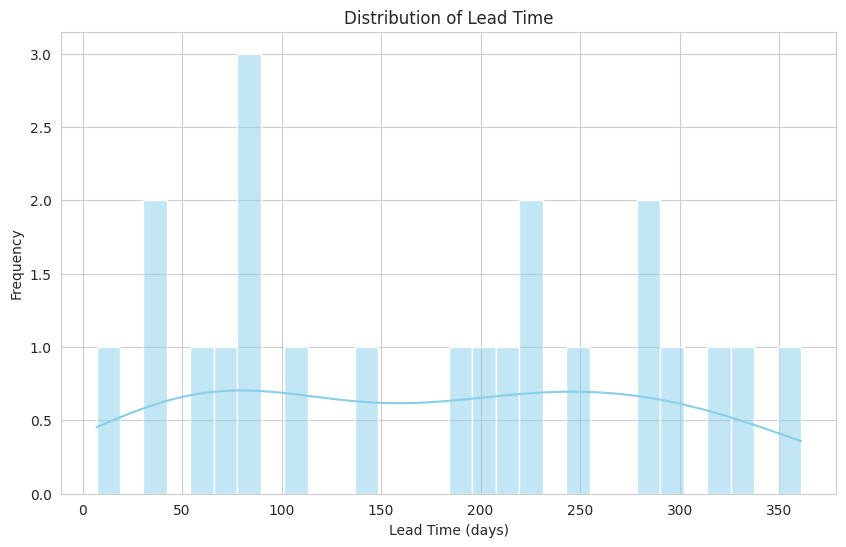

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a histogram for 'LEAD TIME'
plt.figure(figsize=(10, 6))
sns.histplot(df['LEAD TIME'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time (days)')
plt.ylabel('Frequency')
plt.show()

In [11]:
print("\nSummary Statistics for 'LEAD TIME':")
display(df['LEAD TIME'].describe())


Summary Statistics for 'LEAD TIME':


,LEAD TIME
count,22.000000
mean,176.818182
std,110.360291
min,7.000000
25%,79.250000
50%,194.000000
75%,275.500000
max,361.000000


## Final Insights and Next Steps

Based on the initial exploratory analysis, correlation, Chi-Square tests, and T-tests, here's a summary of the insights gained regarding booking cancellations and potential next steps:

### Key Findings:

1.  **Lead Time Correlation:** 'LEAD TIME' showed a positive correlation (0.296) with `CANCELLED`. This suggests that bookings made further in advance might be slightly more prone to cancellation. This is a common pattern in hospitality where longer booking windows offer more opportunities for plans to change.
2.  **Negative Correlations:** 'STAYS IN WEEK NIGHTS' and 'PREVIOUS CANCELLATION' had the strongest negative correlations with `CANCELLED`. This indicates that bookings with more weeknight stays or those with a history of previous cancellations (implying the customer is not a first-time canceller) are less likely to be cancelled in the current booking. This might be counter-intuitive for 'PREVIOUS CANCELLATION' and warrants further investigation.
3.  **No Significant Associations (Chi-Square):** Neither 'Column1' (Hotel Type) nor 'DEPOSITE TYPE' showed a statistically significant association with `CANCELLED` based on the Chi-Square tests. This implies that, within this dataset, the type of hotel or the deposit policy does not significantly influence the likelihood of cancellation.
4.  **No Significant Mean Differences (T-Test):** The T-tests revealed no statistically significant difference in the mean 'LEAD TIME' or 'ADDRESS' between cancelled and non-cancelled bookings. While 'LEAD TIME' had a positive correlation, the T-test suggests that the *average* lead time itself isn't a strong differentiator between the two groups, but rather the variability or other factors might be at play.

### Potential Next Steps:

1.  **Deep Dive into 'PREVIOUS CANCELLATION':** The negative correlation with 'PREVIOUS CANCELLATION' is interesting. It would be beneficial to understand if this column represents the count of previous cancellations, or a flag. A deeper analysis could involve:
    *   Examining the distribution of this variable.
    *   Segmenting customers by their 'PREVIOUS CANCELLATION' count and analyzing their cancellation behavior.
2.  **Explore Other Categorical Variables:** While 'Column1' and 'DEPOSITE TYPE' showed no significant association, other categorical variables like 'MARKET SEGEMENT', 'DISTRIBUTION CHANNEL', 'RESERVED ROOM TYPE', 'CUSTOMER TYPE', and 'COUNTRY' could be analyzed for their association with 'CANCELLED' using Chi-Square tests.
3.  **Feature Engineering:** Create new features that could better capture cancellation risk. Examples include:
    *   `total_stays_nights` (sum of weekend and week nights).
    *   `family_size` (sum of adults, children, and babies).
    *   Deriving seasonal features from 'ARRIVAL DATE MONTHS' (e.g., 'is_peak_season').
4.  **Outlier Analysis:** Investigate outliers in 'LEAD TIME' and other numerical features, as extreme values can sometimes skew correlation and mean-based tests. The histogram for 'LEAD TIME' suggests a long tail, which might contain interesting cases.
5.  **Predictive Modeling:** Based on these insights, the next logical step would be to build a predictive model to forecast booking cancellations. This would involve:
    *   Selecting relevant features.
    *   Splitting the data into training and testing sets.
    *   Training a classification model (e.g., Logistic Regression, Decision Tree, Random Forest).
    *   Evaluating model performance.
6.  **Visualize Relationships:** Create visualizations (e.g., box plots, violin plots) to visually inspect the relationship between categorical variables and 'CANCELLED', and scatter plots for numerical variables, especially those with interesting correlations.

These steps will provide a more comprehensive understanding of the factors influencing booking cancellations and can inform strategies to mitigate them.

/tmp/ipykernel_604/3976215334.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CANCELLED', y='LEAD TIME', data=df, palette='viridis')


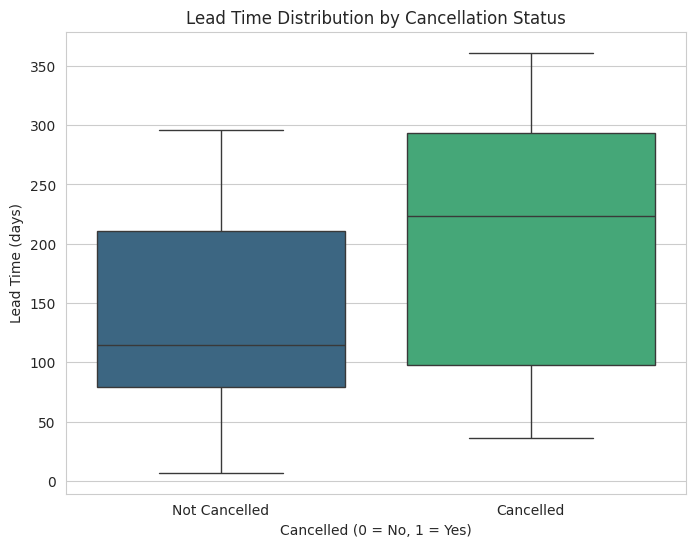

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot to visualize the relationship between 'LEAD TIME' and 'CANCELLED'
plt.figure(figsize=(8, 6))
sns.boxplot(x='CANCELLED', y='LEAD TIME', data=df, palette='viridis')
plt.title('Lead Time Distribution by Cancellation Status')
plt.xlabel('Cancelled (0 = No, 1 = Yes)')
plt.ylabel('Lead Time (days)')
plt.xticks([0, 1], ['Not Cancelled', 'Cancelled'])
plt.show()